# Text Trends for for Philippine Youtube Video Titles


## Rationale

## Why Youtube Videos

- Content creation has exploded in the Philippines. Lawmakers, news anchors, and people around social media have been talking about vloggers with great ambivelence.
- Content creation isn't for everybody, as we've seen on the news and in social media, people go to dangerous and even illegal lengths to engage their audience.
- As difficult and seemingly saturated content creation has become from the recent attention, still, there are many things that content creators can do to help grow their audience without sacrificing dignity, sanity, and overall wellness.
- This data analysis hopes to help in one factor that's crucial to content creation -- The Title.

## Why Titles

- Titles in Youtube Videos specifically serve more than its descriptive purpose, it elevates or dealevates the video itself.
- It's incomparable to, for example, salutations in emails or greetings in real life.
- Simply said, titles in Youtube Videos make or break an impression of viewers on your video.
- Although thumbnails play 50% or even more of the same role, this analysis will focus on titles.


In [2]:
import pandas as pd 
import numpy as np 

## Dataset Explanation

- The dataset collected is from kaggle as the dataset entitled "[Trending Youtube Video Statistics](https://www.kaggle.com/datasets/asaniczka/trending-youtube-videos-113-countries)"
- The dataset takes snapshots of the details of a videos such as likes, views, and comment counts in one day intervals.
- The dataset in total has 243,008 unique video titles from trending videos globally.
- The dataset has videos published as early as September of 2023 to March 2025
- There are many video duplicates since videos usually trend long enough to have multiple snapshots


In [3]:
df = pd.read_csv('./trending_yt_videos_113_countries.csv')
df

,title,channel_name,daily_rank,daily_movement,weekly_movement,snapshot_date,country,view_count,like_count,comment_count,description,thumbnail_url,video_id,channel_id,video_tags,kind,publish_date,langauge
0,cde Blessed Geza announces 31 March as a day o...,TechMag TV,1,0,0,2025-03-27,ZW,318650,5337,1781,cde Blessed Geza announces 31 March as a day o...,https://i.ytimg.com/vi/2arSMa5Lflw/mqdefault.jpg,2arSMa5Lflw,UC5Cs-mGmXWdteODG5MyOlyw,NaN,youtube#video,2025-03-18 00:00:00+00:00,en
1,The Incredible Dog that Picks Up a Girl from S...,Amsi,2,0,48,2025-03-27,ZW,9469200,411130,890,Amsi #shorts \n\nNote: This video is made for ...,https://i.ytimg.com/vi/Av43x7eJM7Y/mqdefault.jpg,Av43x7eJM7Y,UCMEjA10VE3iRLkQ-VEeXDdQ,NaN,youtube#video,2025-03-19 00:00:00+00:00,en-US
2,"Zimbabwe: Opposition Leader ""Bombshell"" Challe...",Firstpost,3,0,2,2025-03-27,ZW,164942,1008,174,"Zimbabwe: Opposition Leader ""Bombshell"" Challe...",https://i.ytimg.com/vi/X6CFLaP_t3E/mqdefault.jpg,X6CFLaP_t3E,UCz8QaiQxApLq8sLNcszYyJw,"firstpost, firstpost africa, alyson le grange,...",youtube#video,2025-03-14 00:00:00+00:00,NaN
3,Cassper Nyovest - Kusho Bani (Official Music V...,CassperNyovestVEVO,4,0,11,2025-03-27,ZW,1113449,55155,4851,'Kusho Bani' out now: https://casspernyovest.b...,https://i.ytimg.com/vi/ISRdOyYupMg/mqdefault.jpg,ISRdOyYupMg,UC5eT_421evkBZJu7pIOGdsA,"Cassper Nyovest, Universal Music (Pty) Ltd., H...",youtube#video,2025-03-18 00:00:00+00:00,NaN
4,The most mysterious house in the world 😱,Amsi,5,8,-1,2025-03-27,ZW,8897422,358568,2532,Amsi #shorts,https://i.ytimg.com/vi/oPRgtXkP9Bk/mqdefault.jpg,oPRgtXkP9Bk,UCMEjA10VE3iRLkQ-VEeXDdQ,NaN,youtube#video,2025-03-12 00:00:00+00:00,en-US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2918122,انهيار الطبيبة هديل الجمل عند وصول عائلتها جرح...,شبكة قدس الاخبارية,46,4,4,2023-10-26,AE,1064501,8823,815,تابعوا #شبكة_قدس عبر المنصات المختلفة:\nFacebo...,https://i.ytimg.com/vi/OcPejiPT07U/mqdefault.jpg,OcPejiPT07U,UCFFuMGTQXLitNuiU4SIe5vQ,"فلسطين, القدس, غزة, تاريخ فلسطين, عاصمة فلسطين...",youtube#video,2023-10-22 15:04:53+00:00,ar
2918123,بدهم ايانا نترك بيتنا !,وليد ونور | Waleed & Noor,47,3,3,2023-10-26,AE,413648,36218,2070,حساباتنا على مواقع التواصل الإجتماعي : \n\nولي...,https://i.ytimg.com/vi/qX9XD-5ZGIE/mqdefault.jpg,qX9XD-5ZGIE,UCHywC_HXMWAM6-XvjY8gnUw,"وليد ونور, نور غسان, وليدمقداد, الوليد مقداد, ...",youtube#video,2023-10-22 16:10:45+00:00,ar
2918124,"""إسرائيل"" تنزف!.. هل ينهار الاقتصاد ""الإسرائيل...",المخبر الاقتصادي - Mokhbir Eqtisadi,48,2,2,2023-10-26,AE,2076478,197026,12930,لو انت شركة أو تاجر اتواصل مع شركة Talaviet ل...,https://i.ytimg.com/vi/s7n2wzIWjtY/mqdefault.jpg,s7n2wzIWjtY,UC4kRorAXuIkyIX6vwXKaLWg,"المخبر الاقتصادي, اخبار الاقتصاد, اسعار العملا...",youtube#video,2023-10-19 17:00:08+00:00,ar
2918125,حرقت جوال فارس وأهديته آيفون 15 😨🔥,VIRUS,49,1,1,2023-10-26,AE,1190917,88558,4053,متجر باور إستخدم كود ( VRS )\nhttps://powrstor...,https://i.ytimg.com/vi/BtV1EVQV3k8/mqdefault.jpg,BtV1EVQV3k8,UCf6NFXV7Pgcft8X6rDjjibg,"Vlog, Montage, Youtube, فلوق, فلوقات, مونتاج, ...",youtube#video,2023-10-19 10:51:28+00:00,ar


In [4]:
# Looking at how frequently the dataset updates
snapshot_sequence = df['snapshot_date'].sort_values().unique()
snapshot_sequence

array(['2023-10-26', '2023-10-27', '2023-10-28', '2023-10-29',
       '2023-10-30', '2023-10-31', '2023-11-01', '2023-11-02',
       '2023-11-03', '2023-11-04', '2023-11-05', '2023-11-06',
       '2023-11-07', '2023-11-08', '2023-11-09', '2023-11-10',
       '2023-11-11', '2023-11-12', '2023-11-13', '2023-11-14',
       '2023-11-15', '2023-11-16', '2023-11-17', '2023-11-18',
       '2023-11-19', '2023-11-20', '2023-11-21', '2023-11-22',
       '2023-11-23', '2023-11-24', '2023-11-25', '2023-11-26',
       '2023-11-27', '2023-11-28', '2023-11-29', '2023-11-30',
       '2023-12-01', '2023-12-02', '2023-12-03', '2023-12-04',
       '2023-12-05', '2023-12-06', '2023-12-07', '2023-12-08',
       '2023-12-09', '2023-12-10', '2023-12-11', '2023-12-12',
       '2023-12-13', '2023-12-14', '2023-12-15', '2023-12-16',
       '2023-12-17', '2023-12-18', '2023-12-19', '2023-12-20',
       '2023-12-21', '2023-12-22', '2023-12-23', '2023-12-24',
       '2023-12-25', '2023-12-26', '2023-12-27', '2023-

In [5]:
# Earliest and oldest publish date in entire dataset
df['publish_date'].min(), df['publish_date'].max()

('2023-09-20 02:22:46+00:00', '2025-03-27 00:00:00+00:00')

In [6]:
# Both queries result in the same number of rows
# The first iteration of this experiment looked at Philippine-only trending videos but video titles contained too many videos in other languages
# df_ph = df[(df['country']=='PH')].reset_index(drop=True)

df_ph = df[(df['country']=='PH') & (df['langauge']=='fil')].reset_index(drop=True)
# df_ph = df[(df['country']=='PH') & (df['langauge']=='fil')].reset_index(drop=True)

df_ph

,title,channel_name,daily_rank,daily_movement,weekly_movement,snapshot_date,country,view_count,like_count,comment_count,description,thumbnail_url,video_id,channel_id,video_tags,kind,publish_date,langauge
0,AWAY,Geo Ong,38,-7,-31,2025-03-27,PH,1859087,76639,6313,LAZADA MASID : https://s.lazada.com.ph/s.6y5Z...,https://i.ytimg.com/vi/0t17MCmYUFs/mqdefault.jpg,0t17MCmYUFs,UCtoKGjdpzrXCI_3-WSAs_ng,"geo ong, vlog, vlogger, ybs, travel, adventure...",youtube#video,2025-03-19 00:00:00+00:00,fil
1,AWAY,Geo Ong,31,-1,19,2025-03-26,PH,1804764,75972,6281,LAZADA MASID : https://s.lazada.com.ph/s.6y5Z...,https://i.ytimg.com/vi/0t17MCmYUFs/mqdefault.jpg,0t17MCmYUFs,UCtoKGjdpzrXCI_3-WSAs_ng,"geo ong, vlog, vlogger, ybs, travel, adventure...",youtube#video,2025-03-19 00:00:00+00:00,fil
2,Quiapo Food Trip by Alex Gonzaga,Alex Gonzaga Official,45,-2,-40,2025-03-26,PH,3398224,79215,2756,Subscribe to Ka-maintenance\nhttps://youtube.c...,https://i.ytimg.com/vi/fupEjNyFK88/mqdefault.jpg,fupEjNyFK88,UC6N-9Wh0DYhDI8sQS7jwjVA,"Alex gonzaga, Alex vlog, New vlog, Ivana alawi...",youtube#video,2025-03-16 00:00:00+00:00,fil
3,"Kasalan, naudlot dahil si groom, ginayuma dium...",GMA Public Affairs,47,-2,-33,2025-03-26,PH,2674408,15391,2116,"Aired (March 16, 2025):\n\nKASALAN SA CAGAYAN ...",https://i.ytimg.com/vi/La3gioej0pc/mqdefault.jpg,La3gioej0pc,UCj5RwDivLksanrNvkW0FB4w,"Feature, series: Kapuso Mo Jessica Soho, Topic...",youtube#video,2025-03-17 00:00:00+00:00,fil
4,AWAY,Geo Ong,30,-10,20,2025-03-25,PH,1740746,75112,6245,LAZADA MASID : https://s.lazada.com.ph/s.6y5Z...,https://i.ytimg.com/vi/0t17MCmYUFs/mqdefault.jpg,0t17MCmYUFs,UCtoKGjdpzrXCI_3-WSAs_ng,"geo ong, vlog, vlogger, ybs, travel, adventure...",youtube#video,2025-03-19 00:00:00+00:00,fil
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1534,Jail For A Day by Alex Gonzaga,Alex Gonzaga Official,7,43,43,2023-10-26,PH,1264084,43138,1876,Subscribe to Ka-maintenance\nhttps://youtube.c...,https://i.ytimg.com/vi/cENUPdPC6v0/mqdefault.jpg,cENUPdPC6v0,UC6N-9Wh0DYhDI8sQS7jwjVA,"Alex gonzaga, Alex g, New vlog, Alex vlog, Ton...",youtube#video,2023-10-22 05:01:18+00:00,fil
1535,ANG PAG DATING,Geo Ong,18,32,32,2023-10-26,PH,1711506,82852,4364,LAZADA MASID : https://s.lazada.com.ph/s.6y5Z...,https://i.ytimg.com/vi/tnnu67-sgOM/mqdefault.jpg,tnnu67-sgOM,UCtoKGjdpzrXCI_3-WSAs_ng,"geo ong, vlog, vlogger, ybs, travel, adventure...",youtube#video,2023-10-23 10:45:02+00:00,fil
1536,RamPANALONG Gift Kay Nanay Rosario | VICE GANDA,Vice Ganda,20,30,30,2023-10-26,PH,569531,16090,332,Ganda ka? Edi subscribe na sa aking YouTube ch...,https://i.ytimg.com/vi/Wpv1Sy1pJdg/mqdefault.jpg,Wpv1Sy1pJdg,UCZ1PkXDIb_ybGu-3cxMm6oQ,"vice ganda, vice, ganda, meme vice, meme, vice...",youtube#video,2023-10-23 11:30:09+00:00,fil
1537,I Opened the First Ever MCDOLLIBEE TRUCK!,Adam Alejo,31,19,19,2023-10-26,PH,219022,6939,412,Special Thanks to Street Automotive: https://w...,https://i.ytimg.com/vi/ZftgzHytXFk/mqdefault.jpg,ZftgzHytXFk,UC9CATkh6h36V8vT82nJFIIw,"Mcdollibee part 2, adam alejo, mcdojollibee",youtube#video,2023-10-24 11:05:47+00:00,fil


In [7]:
df_ph.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1539 entries, 0 to 1538
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            1539 non-null   object
 1   channel_name     1539 non-null   object
 2   daily_rank       1539 non-null   int64 
 3   daily_movement   1539 non-null   int64 
 4   weekly_movement  1539 non-null   int64 
 5   snapshot_date    1539 non-null   object
 6   country          1539 non-null   object
 7   view_count       1539 non-null   int64 
 8   like_count       1539 non-null   int64 
 9   comment_count    1539 non-null   int64 
 10  description      1516 non-null   object
 11  thumbnail_url    1539 non-null   object
 12  video_id         1539 non-null   object
 13  channel_id       1539 non-null   object
 14  video_tags       1436 non-null   object
 15  kind             1539 non-null   object
 16  publish_date     1539 non-null   object
 17  langauge         1539 non-null   

Due to time contraints, only videos in the Philippines and are in Filipino are considered. If we isolate to the Philippines, we will see videos in many other languages that would take too much time to clean with regex. In total, we will have 1,539 rows if we isolate philippine trending videos that are in Filipino. Once we filter by unique names, we have 282 unique video titles in total.


In [8]:
df_ph['title'].nunique()

282

In [9]:
# df_ph.groupby(['title']).mean()
# Dropping columns we won't use in the following analysis

def custom_agg(col):
    if col.name == "daily_rank":
        return col.min()
    # Prevent error and assuming that all videos should have the same tags and are unchanging
    elif col.name == "video_tags":
        return col.iloc[0]
    else:
        return col.max()

df_ph = df_ph.drop(columns=['channel_name', 'snapshot_date', 'country', 'description', 'thumbnail_url', 'video_id','video_id', 'kind', 'channel_id', 'langauge'])
df_ph = df_ph.groupby(['title']).agg(custom_agg)

In [10]:
# Fix title as index
df_ph.reset_index(inplace=True)
df_ph

,title,daily_rank,daily_movement,weekly_movement,view_count,like_count,comment_count,video_tags,publish_date
0,"""My Battle Against Cancer"" - Doc Willie Ong",19,25,31,2055492,101036,418,"heal, health, home remedies, doctor, weight lo...",2024-09-14 00:00:00+00:00
1,'Abel Villarama: Armado’ FULL MOVIE | Ace Vergel,14,36,36,1693216,8871,213,"ABS-CBN, Star Cinema, ABS-CBN Star Cinema, ABS...",2024-09-01 00:00:00+00:00
2,"'Home Sic Home' FULL MOVIE | Dolphy, Babalu",20,25,30,1771232,7329,383,"ABS-CBN, Star Cinema, ABS-CBN Star Cinema, ABS...",2024-07-14 00:00:00+00:00
3,"'Hostage' FULL MOVIE | Cesar Montano, Roi Vinz...",9,39,41,3626151,17544,469,"ABS-CBN, Star Cinema, ABS-CBN Star Cinema, ABS...",2024-09-10 00:00:00+00:00
4,'Naiihi ako sa nerbyos dito': Duterte excuses ...,6,43,44,2492289,21066,28844,"ABS-CBN, ABS-CBN News, ABS-CBN Philippines, Ph...",2024-10-28 00:00:00+00:00
...,...,...,...,...,...,...,...,...,...
277,[FIL] Team Darleng vs Aurora Esports (BO5) Dre...,24,26,26,274660,856,1,"luponwxc, lupon, kuyanic, nico nazario, dota 2...",2024-01-17 00:00:00+00:00
278,[FIL] Team Darleng vs Talon Esports (BO3) Drea...,19,31,31,228742,710,0,"luponwxc, lupon, kuyanic, nico nazario, dota 2...",2024-01-16 00:00:00+00:00
279,‘'Di Puwedeng Hindi Puwede!' FULL MOVIE | Robi...,5,37,45,3951102,20344,636,"ABS-CBN, Star Cinema, ABS-CBN Star Cinema, ABS...",2024-07-14 00:00:00+00:00
280,‘Type Kita... Walang Kokontra’ FULL MOVIE | Ce...,11,37,39,1695793,7663,171,"ABS-CBN, Star Cinema, ABS-CBN Star Cinema, ABS...",2024-10-13 00:00:00+00:00


## Cleaning Stop words

- Due to this project's kernel running on python 3.13, spacy cannot be installed on this version so we will directly copy stop words from their [github page](https://github.com/explosion/spaCy/blob/master/spacy/lang/tl/stop_words.py)


In [11]:
FILIPINO_STOP_WORDS = set(
    """
akin
aking
ako
alin
am
amin
aming
ang
ano
anumang
apat
at
atin
ating
ay
bababa
bago
bakit
bawat
bilang
dahil
dalawa
dapat
din
dito
doon
gagawin
gayunman
ginagawa
ginawa
ginawang
gumawa
gusto
habang
hanggang
hindi
huwag
iba
ibaba
ibabaw
ibig
ikaw
ilagay
ilalim
ilan
inyong
isa
isang
itaas
ito
iyo
iyon
iyong
ka
kahit
kailangan
kailanman
kami
kanila
kanilang
kanino
kanya
kanyang
kapag
kapwa
karamihan
katiyakan
katulad
kaya
kaysa
ko
kong
kulang
kumuha
kung
laban
lahat
lamang
likod
lima
maaari
maaaring
maging
mahusay
makita
marami
marapat
masyado
may
mayroon
mga
minsan
mismo
mula
muli
na
nabanggit
naging
nagkaroon
nais
nakita
namin
napaka
narito
nasaan
ng
ngayon
ni
nila
nilang
nito
niya
niyang
noon
o
pa
paano
pababa
paggawa
pagitan
pagkakaroon
pagkatapos
palabas
pamamagitan
panahon
pangalawa
para
paraan
pareho
pataas
pero
pumunta
pumupunta
sa
saan
sabi
sabihin
sarili
sila
sino
siya
tatlo
tayo
tulad
tungkol
una
walang
""".split()
)

In [12]:
ENGLISH_STOP_WORDS = set(
    """
a about above across after afterwards again against all almost alone along
already also although always am among amongst amount an and another any anyhow
anyone anything anyway anywhere are around as at

back be became because become becomes becoming been before beforehand behind
being below beside besides between beyond both bottom but by

call can cannot ca could

did do does doing done down due during

each eight either eleven else elsewhere empty enough even ever every
everyone everything everywhere except

few fifteen fifty first five for former formerly forty four from front full
further

get give go

had has have he hence her here hereafter hereby herein hereupon hers herself
him himself his how however hundred

i if in indeed into is it its itself

keep

last latter latterly least less

just

made make many may me meanwhile might mine more moreover most mostly move much
must my myself

name namely neither never nevertheless next nine no nobody none noone nor not
nothing now nowhere

of off often on once one only onto or other others otherwise our ours ourselves
out over own

part per perhaps please put

quite

rather re really regarding

same say see seem seemed seeming seems serious several she should show side
since six sixty so some somehow someone something sometime sometimes somewhere
still such

take ten than that the their them themselves then thence there thereafter
thereby therefore therein thereupon these they third this those though three
through throughout thru thus to together too top toward towards twelve twenty
two

under until up unless upon us used using

various very very via was we well were what whatever when whence whenever where
whereafter whereas whereby wherein whereupon wherever whether which while
whither who whoever whole whom whose why will with within without would

yet you your yours yourself yourselves
""".split()
)

In [13]:
STOPWORDS = ENGLISH_STOP_WORDS.union(FILIPINO_STOP_WORDS)

## Tokenize


In [14]:
import nltk
# nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

In [15]:
df_ph['title']

0            "My Battle Against Cancer" - Doc Willie Ong
1       'Abel Villarama: Armado’ FULL MOVIE | Ace Vergel
2            'Home Sic Home' FULL MOVIE | Dolphy, Babalu
3      'Hostage' FULL MOVIE | Cesar Montano, Roi Vinz...
4      'Naiihi ako sa nerbyos dito': Duterte excuses ...
                             ...                        
277    [FIL] Team Darleng vs Aurora Esports (BO5) Dre...
278    [FIL] Team Darleng vs Talon Esports (BO3) Drea...
279    ‘'Di Puwedeng Hindi Puwede!' FULL MOVIE | Robi...
280    ‘Type Kita... Walang Kokontra’ FULL MOVIE | Ce...
281                “Dilaw” - Maki (Official Music Video)
Name: title, Length: 282, dtype: object

In [16]:
import re 

def removeSpecials(text):
    return re.sub(r"[^a-zA-Z0-9]", "", text)

def tokenize(text):
    text = text.lower()
    tokens = word_tokenize(text)
    # Remove stopwords and remove special characters
    tokens = [removeSpecials(token) for token in  tokens if token not in STOPWORDS]
    
    # Remove empty ones
    tokens = [token for token in tokens if len(token) > 1]
    # print(tokens)
    return tokens



df_ph["tokens"] = df_ph['title'].apply(tokenize)
df_ph

,title,daily_rank,daily_movement,weekly_movement,view_count,like_count,comment_count,video_tags,publish_date,tokens
0,"""My Battle Against Cancer"" - Doc Willie Ong",19,25,31,2055492,101036,418,"heal, health, home remedies, doctor, weight lo...",2024-09-14 00:00:00+00:00,"[battle, cancer, doc, willie, ong]"
1,'Abel Villarama: Armado’ FULL MOVIE | Ace Vergel,14,36,36,1693216,8871,213,"ABS-CBN, Star Cinema, ABS-CBN Star Cinema, ABS...",2024-09-01 00:00:00+00:00,"[abel, villarama, armado, movie, ace, vergel]"
2,"'Home Sic Home' FULL MOVIE | Dolphy, Babalu",20,25,30,1771232,7329,383,"ABS-CBN, Star Cinema, ABS-CBN Star Cinema, ABS...",2024-07-14 00:00:00+00:00,"[home, sic, home, movie, dolphy, babalu]"
3,"'Hostage' FULL MOVIE | Cesar Montano, Roi Vinz...",9,39,41,3626151,17544,469,"ABS-CBN, Star Cinema, ABS-CBN Star Cinema, ABS...",2024-09-10 00:00:00+00:00,"[hostage, movie, cesar, montano, roi, vinzon, ..."
4,'Naiihi ako sa nerbyos dito': Duterte excuses ...,6,43,44,2492289,21066,28844,"ABS-CBN, ABS-CBN News, ABS-CBN Philippines, Ph...",2024-10-28 00:00:00+00:00,"[naiihi, nerbyos, duterte, excuses, raising, v..."
...,...,...,...,...,...,...,...,...,...,...
277,[FIL] Team Darleng vs Aurora Esports (BO5) Dre...,24,26,26,274660,856,1,"luponwxc, lupon, kuyanic, nico nazario, dota 2...",2024-01-17 00:00:00+00:00,"[fil, team, darleng, vs, aurora, esports, bo5,..."
278,[FIL] Team Darleng vs Talon Esports (BO3) Drea...,19,31,31,228742,710,0,"luponwxc, lupon, kuyanic, nico nazario, dota 2...",2024-01-16 00:00:00+00:00,"[fil, team, darleng, vs, talon, esports, bo3, ..."
279,‘'Di Puwedeng Hindi Puwede!' FULL MOVIE | Robi...,5,37,45,3951102,20344,636,"ABS-CBN, Star Cinema, ABS-CBN Star Cinema, ABS...",2024-07-14 00:00:00+00:00,"[di, puwedeng, puwede, movie, robin, padilla, ..."
280,‘Type Kita... Walang Kokontra’ FULL MOVIE | Ce...,11,37,39,1695793,7663,171,"ABS-CBN, Star Cinema, ABS-CBN Star Cinema, ABS...",2024-10-13 00:00:00+00:00,"[type, kita, kokontra, movie, cesar, montano, ..."


## Extract Bigrams


In [17]:
from nltk.util import ngrams
from collections import Counter

flat_tokens = [token for tokens in df_ph["tokens"] for token in tokens]
flat_bigrams = [f"{w1} {w2}" for tokens in df_ph["tokens"] for w1, w2 in ngrams(tokens, 2)]

top_words = Counter(flat_tokens).most_common(15)
top_bigrams = Counter(flat_bigrams).most_common(15)

top_words,top_bigrams

([('episode', 69),
  ('gonzaga', 43),
  ('2024', 42),
  ('alex', 42),
  ('batang', 36),
  ('quiapo', 36),
  ('fpj', 35),
  ('vs', 29),
  ('subs', 26),
  ('mo', 25),
  ('2023', 25),
  ('eng', 25),
  ('kapuso', 24),
  ('jessica', 24),
  ('soho', 24)],
 [('alex gonzaga', 42),
  ('fpj batang', 35),
  ('batang quiapo', 35),
  ('quiapo episode', 35),
  ('eng subs', 25),
  ('kapuso mo', 24),
  ('mo jessica', 24),
  ('jessica soho', 24),
  ('vice ganda', 18),
  ('2023 eng', 18),
  ('2024 episode', 14),
  ('episode replay', 14),
  ('family feud', 12),
  ('kmjs livestream', 11),
  ('2025 episode', 9)])

## Generate Categories

- Using Youtube Data API v3, we can perform a get request for their video tags used in youtube videos in the Philippines
- The choice for the Zero-shot classifier model is based on support of the filipino language and english
- This is the only publicly avaialble model on huggingface

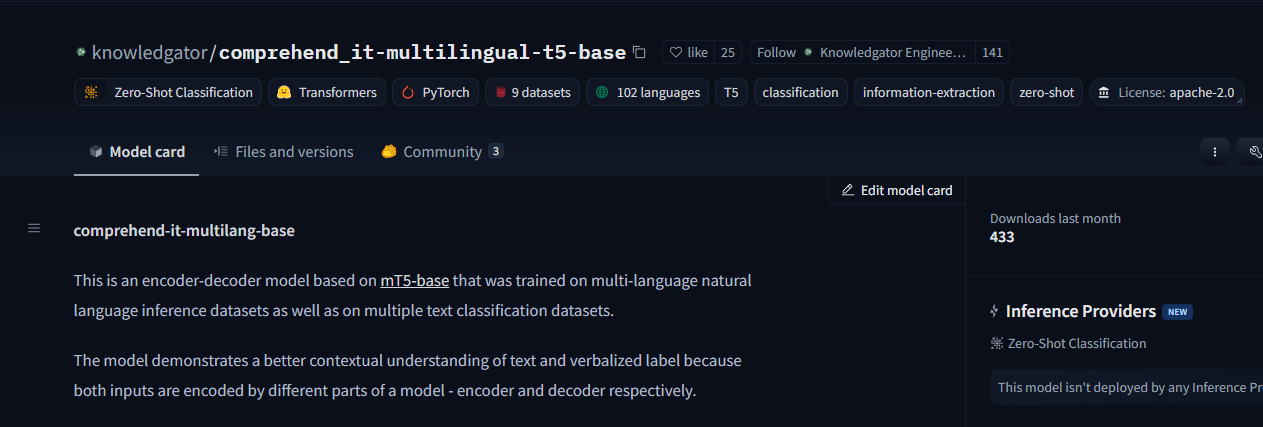


In [18]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
# classifier = pipeline("zero-shot-classification", model="knowledgator/comprehend_it-multilingual-t5-base")
# Broken because it doesn't support the latest version 

c:\Users\User\miniconda3\envs\data_science\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use cuda:0


### Categories from Google
- Using the categories found under google's api, we can generate the same exact categories found in youtube videos by calling their api

In [ ]:
API_KEY = ''

In [ ]:
from googleapiclient.discovery import build
youtube = build('youtube', 'v3', developerKey=API_KEY)

# Fetching for ph 
response = youtube.videoCategories().list(
    part="snippet",
    regionCode="PH"
).execute()

for item in response['items']:
    print(f"{item['id']}: {item['snippet']['title']}")

1: Film & Animation
2: Autos & Vehicles
10: Music
15: Pets & Animals
17: Sports
18: Short Movies
19: Travel & Events
20: Gaming
21: Videoblogging
22: People & Blogs
23: Comedy
24: Entertainment
25: News & Politics
26: Howto & Style
27: Education
28: Science & Technology
30: Movies
31: Anime/Animation
32: Action/Adventure
33: Classics
34: Comedy
35: Documentary
36: Drama
37: Family
38: Foreign
39: Horror
40: Sci-Fi/Fantasy
41: Thriller
42: Shorts
43: Shows
44: Trailers


In [35]:
candidate_labels = [category['snippet']['title'] for category in response['items']]
candidate_labels

['Film & Animation',
 'Autos & Vehicles',
 'Music',
 'Pets & Animals',
 'Sports',
 'Short Movies',
 'Travel & Events',
 'Gaming',
 'Videoblogging',
 'People & Blogs',
 'Comedy',
 'Entertainment',
 'News & Politics',
 'Howto & Style',
 'Education',
 'Science & Technology',
 'Movies',
 'Anime/Animation',
 'Action/Adventure',
 'Classics',
 'Comedy',
 'Documentary',
 'Drama',
 'Family',
 'Foreign',
 'Horror',
 'Sci-Fi/Fantasy',
 'Thriller',
 'Shorts',
 'Shows',
 'Trailers']

In [36]:
# In generating tags, empty video tags will be replaced with the video title as input
def categorize_tags(row):
    tags = row['video_tags']
    
    if pd.isna(tags):
        # print(row)
        tags = ", ".join(row['tokens'])
        result = classifier(tags, candidate_labels)
        return result['labels'][0] #highest
    else:
        result = classifier(tags, candidate_labels)
        return result['labels'][0]

# Apply categorization
df_ph['category'] = df_ph.apply(categorize_tags, axis=1)


## Generate Title Length

- We are looking at this column to see how length affects other metrics in analysis


In [37]:
def getLength(text):
    return len(text)

df_ph['title_len'] = df_ph['tokens'].apply(getLength)
df_ph

,title,daily_rank,daily_movement,weekly_movement,view_count,like_count,comment_count,video_tags,publish_date,tokens,category,title_len
0,"""My Battle Against Cancer"" - Doc Willie Ong",19,25,31,2055492,101036,418,"heal, health, home remedies, doctor, weight lo...",2024-09-14 00:00:00+00:00,"[battle, cancer, doc, willie, ong]",Family,5
1,'Abel Villarama: Armado’ FULL MOVIE | Ace Vergel,14,36,36,1693216,8871,213,"ABS-CBN, Star Cinema, ABS-CBN Star Cinema, ABS...",2024-09-01 00:00:00+00:00,"[abel, villarama, armado, movie, ace, vergel]",Movies,6
2,"'Home Sic Home' FULL MOVIE | Dolphy, Babalu",20,25,30,1771232,7329,383,"ABS-CBN, Star Cinema, ABS-CBN Star Cinema, ABS...",2024-07-14 00:00:00+00:00,"[home, sic, home, movie, dolphy, babalu]",Movies,6
3,"'Hostage' FULL MOVIE | Cesar Montano, Roi Vinz...",9,39,41,3626151,17544,469,"ABS-CBN, Star Cinema, ABS-CBN Star Cinema, ABS...",2024-09-10 00:00:00+00:00,"[hostage, movie, cesar, montano, roi, vinzon, ...",Movies,8
4,'Naiihi ako sa nerbyos dito': Duterte excuses ...,6,43,44,2492289,21066,28844,"ABS-CBN, ABS-CBN News, ABS-CBN Philippines, Ph...",2024-10-28 00:00:00+00:00,"[naiihi, nerbyos, duterte, excuses, raising, v...",News & Politics,7
...,...,...,...,...,...,...,...,...,...,...,...,...
277,[FIL] Team Darleng vs Aurora Esports (BO5) Dre...,24,26,26,274660,856,1,"luponwxc, lupon, kuyanic, nico nazario, dota 2...",2024-01-17 00:00:00+00:00,"[fil, team, darleng, vs, aurora, esports, bo5,...",Gaming,14
278,[FIL] Team Darleng vs Talon Esports (BO3) Drea...,19,31,31,228742,710,0,"luponwxc, lupon, kuyanic, nico nazario, dota 2...",2024-01-16 00:00:00+00:00,"[fil, team, darleng, vs, talon, esports, bo3, ...",Gaming,14
279,‘'Di Puwedeng Hindi Puwede!' FULL MOVIE | Robi...,5,37,45,3951102,20344,636,"ABS-CBN, Star Cinema, ABS-CBN Star Cinema, ABS...",2024-07-14 00:00:00+00:00,"[di, puwedeng, puwede, movie, robin, padilla, ...",Movies,8
280,‘Type Kita... Walang Kokontra’ FULL MOVIE | Ce...,11,37,39,1695793,7663,171,"ABS-CBN, Star Cinema, ABS-CBN Star Cinema, ABS...",2024-10-13 00:00:00+00:00,"[type, kita, kokontra, movie, cesar, montano, ...",Movies,8


## Saving for StreamLit

- Visualizations will all be done in seperate code
- 3 Exports in Total


In [38]:
top_words_df = pd.DataFrame(top_words, columns=["word", "word_count"])
top_bigrams_df = pd.DataFrame(top_bigrams, columns=["bigram", "bigram_count"])


top_words_df.to_csv("top_words.csv", index=False)
top_bigrams_df.to_csv("top_bigrams.csv", index=False)


df_ph.to_csv("cleaned_youtube_data.csv", index=False)

In [39]:
df_ph.columns

Index(['title', 'daily_rank', 'daily_movement', 'weekly_movement',
       'view_count', 'like_count', 'comment_count', 'video_tags',
       'publish_date', 'tokens', 'category', 'title_len'],
      dtype='object')